# Fase 2 — Otimização via Algoritmo Genético + Interpretação com LLM
## Câncer de mama: Regressão Linear, Regressão Logística e Random Forest

Este notebook usa as funções de `src/ga_utils.py` (Algoritmo Genético) e `src/llm_utils.py` (integração com o Claude) para:

1. Otimizar os hiperparâmetros dos 3 modelos já treinados em `01_analise_e_modelagem.ipynb`.
2. Rodar 5 experimentos: 3 com configurações diferentes do GA, um por algoritmo (Experimentos 1–3), e mais 2 trocando o algoritmo de seleção e de mutação, pra isolar o efeito de cada operador (Experimentos 4–5).
3. Comparar cada modelo original com sua versão otimizada, no mesmo holdout de teste.
4. Depois do treino, ler as **feature importances** do melhor modelo e exportar as 10 medidas que mais pesaram (`experiments/results/feature_importances.json`) — a API e o Angular consomem esse arquivo no exame simplificado.
5. Pedir ao Claude um **laudo de um paciente** (igual à API/front) e um **relatório dos experimentos** do GA. Os prompts ficam em `src/llm_utils.py`.

O loop de gerações do GA vive em `ga_utils.rodar_ga` — cada célula de experimento só chama essa função passando o algoritmo e os parâmetros do GA (população, gerações, mutação, seleção).

## O que é um Algoritmo Genético (GA)?

*Por que usar uma "busca evolutiva" em vez de testar hiperparâmetros manualmente?*

Um Algoritmo Genético é uma técnica de otimização inspirada na seleção natural. Em vez de testar hiperparâmetros um por um (grid search) ou aleatoriamente (random search), ele mantém uma **população** de soluções candidatas e as faz "evoluir":

- **Indivíduo**: um dict com uma configuração completa de hiperparâmetros de um modelo.
- **Gene**: cada hiperparâmetro individual (uma chave do dict).
- **Fitness**: quão boa é aquela configuração — `0.5·recall + 0.3·F1 + 0.2·accuracy`, medidos por validação cruzada (5-fold).
- **Seleção**: as configurações com melhor fitness têm mais chance de "reproduzir".
- **Crossover**: duas configurações "pais" combinam seus genes para gerar "filhos".
- **Mutação**: pequenas alterações aleatórias, para explorar configurações novas.
- **Elitismo**: as melhores configurações da geração atual sempre sobrevivem para a próxima.

*Por que recall pesa mais na fitness?* Em diagnóstico de câncer, classificar um tumor **maligno como benigno** (falso negativo) é o erro mais grave clinicamente.

*Por que seleção por torneio?* É simples de implementar e funciona bem mesmo quando os fitness estão próximos entre si — sorteia `k` indivíduos, o melhor deles vira pai.

*Por que crossover uniforme?* Os hiperparâmetros não têm uma ordem natural entre si, então decidir gene a gene (independentemente) de qual pai herdar faz mais sentido do que cortar o dict num ponto fixo.

In [1]:
import sys
import json
import random
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ga_utils
import llm_utils

X_train, X_test, y_train, y_test, feature_names, scaler = ga_utils.carregar_dados()
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

RESULTADOS_DIR = Path("..") / "experiments" / "results"
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

Treino: (455, 30) | Teste: (114, 30)


## Baseline (Fase 1) — modelos originais

Métricas obtidas em `01_analise_e_modelagem.ipynb`, no mesmo holdout de teste (20%, `random_state=42`):

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Regressão Linear (limiar 0,5) | 0.9649 | 1.0000 | 0.9048 | 0.9500 |
| Regressão Logística | 0.9649 | 0.9750 | 0.9286 | 0.9512 |
| Random Forest | 0.9737 | 1.0000 | 0.9286 | 0.9630 |

Vamos rodar o GA para tentar melhorar cada um desses três — um experimento por algoritmo, cada um com uma configuração diferente do GA.

## Experimento 1 — GA na Regressão Linear

*Por que o limiar (threshold) entra como gene?* `LinearRegression` não tem hiperparâmetro de regularização como Ridge/Lasso — a única forma de melhorar a classificação sem trocar de modelo é ajustar o limiar que converte a predição contínua em classe 0/1 (hoje fixo em 0,5 no notebook 01). Junto com `fit_intercept` e `positive`, esse é o espaço de busca do GA aqui.

**Configuração deste experimento**: população pequena (10), mutação baixa (10%), 10 gerações.

Geração 0: melhor=0.9722  média=0.7466  mutação=0.100
Geração 1: melhor=0.9722  média=0.9574  mutação=0.100
Geração 2: melhor=0.9722  média=0.9343  mutação=0.100
Geração 3: melhor=0.9722  média=0.9363  mutação=0.100
Geração 4: melhor=0.9722  média=0.9323  mutação=0.100
Geração 5: melhor=0.9722  média=0.9339  mutação=0.100
Geração 6: melhor=0.9774  média=0.9728  mutação=0.100
Geração 7: melhor=0.9774  média=0.9707  mutação=0.100
Geração 8: melhor=0.9774  média=0.9390  mutação=0.100
Geração 9: melhor=0.9774  média=0.9727  mutação=0.100
Geração 10: melhor=0.9774  média=0.9774  mutação=0.100
Geração 11: melhor=0.9774  média=0.9228  mutação=0.100
Geração 12: melhor=0.9774  média=0.9774  mutação=0.100
Geração 13: melhor=0.9774  média=0.9745  mutação=0.100
Geração 14: melhor=0.9774  média=0.9299  mutação=0.100
Geração 15: melhor=0.9774  média=0.8656  mutação=0.100
Geração 16: melhor=0.9774  média=0.9483  mutação=0.100
Geração 17: melhor=0.9774  média=0.9365  mutação=0.100
Geração 18: melhor=0

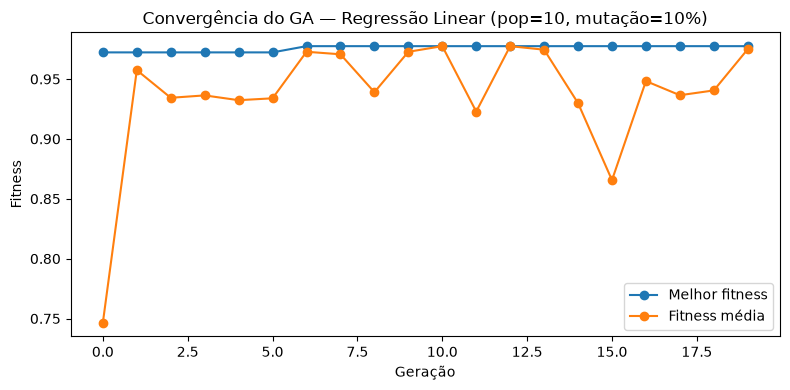

In [ ]:
populacao_rl=10
geracoes_rl=20
mutacao_rl=0.1
populacao, historico_linear, fitnesses, melhor_linear = ga_utils.rodar_ga(
    "regressao_linear", X_train, y_train, X_test, y_test,
    tamanho_populacao=populacao_rl, geracoes=geracoes_rl, mutacao=mutacao_rl, seed=42,
)
print("\nMelhores hiperparâmetros encontrados:", melhor_linear)

pd.DataFrame(historico_linear).to_csv(RESULTADOS_DIR / "fitness_history_regressao_linear.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_linear.json", "w") as f:
    json.dump({"algoritmo": "regressao_linear", "melhor_individuo": melhor_linear}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_linear], [h["melhor"] for h in historico_linear], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_linear], [h["media"] for h in historico_linear], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title(f"Convergência do GA — Regressão Linear (pop={populacao_rl}, mutação={mutacao_rl})")
plt.legend(); plt.tight_layout(); plt.show()

In [3]:
modelo_linear_original = ga_utils.construir_linear(ga_utils.LINEAR_BASELINE)
modelo_linear_original.fit(X_train, y_train)
y_pred_original = ga_utils.prever_linear(modelo_linear_original, X_test, ga_utils.LINEAR_BASELINE)
metricas_linear_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_linear_otimizado = ga_utils.construir_linear(melhor_linear)
modelo_linear_otimizado.fit(X_train, y_train)
y_pred_otimizado = ga_utils.prever_linear(modelo_linear_otimizado, X_test, melhor_linear)
metricas_linear_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_linear_original, metricas_linear_otimizado], index=["Original", "Otimizado (GA)"])

,accuracy,precision,recall,f1
Original,0.964912,1.00000,0.904762,0.95000
Otimizado (GA),0.982456,0.97619,0.976190,0.97619


## Experimento 2 — GA na Regressão Logística

*O que o GA está ajustando aqui?* `C` (inverso da força de regularização), `penalty` (L1 tende a zerar coeficientes menos relevantes, L2 só os encolhe) e `class_weight` (se as classes têm peso igual ou compensam o leve desbalanceamento do dataset).

**Configuração deste experimento**: população maior (20), mutação alta (30%), 10 gerações.

Geração 0: melhor=0.9601  média=0.9522  mutação=0.200
Geração 1: melhor=0.9601  média=0.9577  mutação=0.200
Geração 2: melhor=0.9601  média=0.9575  mutação=0.200
Geração 3: melhor=0.9601  média=0.9575  mutação=0.200
Geração 4: melhor=0.9654  média=0.9586  mutação=0.200
Geração 5: melhor=0.9947  média=0.9632  mutação=0.200
Geração 6: melhor=0.9947  média=0.9612  mutação=0.200
Geração 7: melhor=0.9947  média=0.9649  mutação=0.200
Geração 8: melhor=0.9947  média=0.9776  mutação=0.200
Geração 9: melhor=0.9947  média=0.9773  mutação=0.200
Geração 10: melhor=0.9947  média=0.9802  mutação=0.200
Geração 11: melhor=0.9947  média=0.9825  mutação=0.200
Geração 12: melhor=0.9947  média=0.9814  mutação=0.200
Geração 13: melhor=0.9947  média=0.9842  mutação=0.200
Geração 14: melhor=0.9947  média=0.9750  mutação=0.200

Melhores hiperparâmetros encontrados: {'C': 0.03673046880282847, 'penalty': 'l1', 'class_weight': 'balanced'}


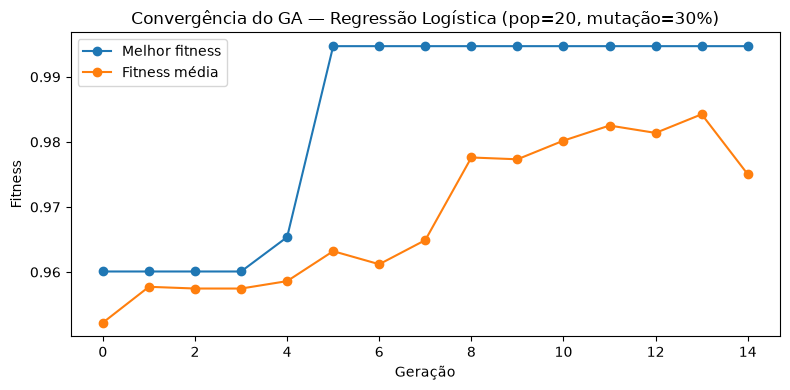

In [ ]:
populacao_rlog=20
geracoes_rlog=15
mutacao_rlog=0.2
populacao, historico_log, fitnesses, melhor_log = ga_utils.rodar_ga(
    "regressao_logistica", X_train, y_train, X_test, y_test,
    tamanho_populacao=populacao_rlog, geracoes=geracoes_rlog, mutacao=mutacao_rlog, seed=42,
)
print("\nMelhores hiperparâmetros encontrados:", melhor_log)

pd.DataFrame(historico_log).to_csv(RESULTADOS_DIR / "fitness_history_regressao_logistica.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_logistica.json", "w") as f:
    json.dump({"algoritmo": "regressao_logistica", "melhor_individuo": melhor_log}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_log], [h["melhor"] for h in historico_log], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_log], [h["media"] for h in historico_log], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title(f"Convergência do GA — Regressão Logística (pop={populacao_rlog}, mutação={mutacao_rlog})")
plt.legend(); plt.tight_layout(); plt.show()

In [5]:
modelo_log_original = ga_utils.construir_log(ga_utils.LOG_BASELINE)
modelo_log_original.fit(X_train, y_train)
y_pred_original = modelo_log_original.predict(X_test)
metricas_log_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_log_otimizado = ga_utils.construir_log(melhor_log)
modelo_log_otimizado.fit(X_train, y_train)
y_pred_otimizado = modelo_log_otimizado.predict(X_test)
metricas_log_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_log_original, metricas_log_otimizado], index=["Original", "Otimizado (GA)"])

,accuracy,precision,recall,f1
Original,0.973684,0.975610,0.952381,0.963855
Otimizado (GA),0.991228,0.976744,1.000000,0.988235


## Experimento 3 — GA no Random Forest

*O que o GA está ajustando aqui?* `n_estimators` (nº de árvores), `max_depth` (profundidade máxima), `min_samples_split`/`min_samples_leaf` (o quão fácil é criar uma nova divisão), `max_features` (quantas features considerar em cada split) e `criterion` (gini vs. entropia).

**Configuração deste experimento**: população média (15), mutação média (20%), mais gerações (20) — o Random Forest já é o melhor baseline, então damos mais tempo de busca pra ele.

Geração 0: melhor=0.9479  média=0.9273  mutação=0.200
Geração 1: melhor=0.9479  média=0.9328  mutação=0.200
Geração 2: melhor=0.9479  média=0.9377  mutação=0.200
Geração 3: melhor=0.9479  média=0.9409  mutação=0.200
Geração 4: melhor=0.9479  média=0.9441  mutação=0.200
Geração 5: melhor=0.9479  média=0.9435  mutação=0.200
Geração 6: melhor=0.9479  média=0.9391  mutação=0.200
Geração 7: melhor=0.9479  média=0.9444  mutação=0.200
Geração 8: melhor=0.9479  média=0.9435  mutação=0.200
Geração 9: melhor=0.9479  média=0.9406  mutação=0.200
Geração 10: melhor=0.9479  média=0.9421  mutação=0.200
Geração 11: melhor=0.9479  média=0.9409  mutação=0.200
Geração 12: melhor=0.9479  média=0.9383  mutação=0.200
Geração 13: melhor=0.9479  média=0.9362  mutação=0.200
Geração 14: melhor=0.9479  média=0.9409  mutação=0.200
Geração 15: melhor=0.9479  média=0.9386  mutação=0.200
Geração 16: melhor=0.9479  média=0.9400  mutação=0.200
Geração 17: melhor=0.9479  média=0.9404  mutação=0.200
Geração 18: melhor=0

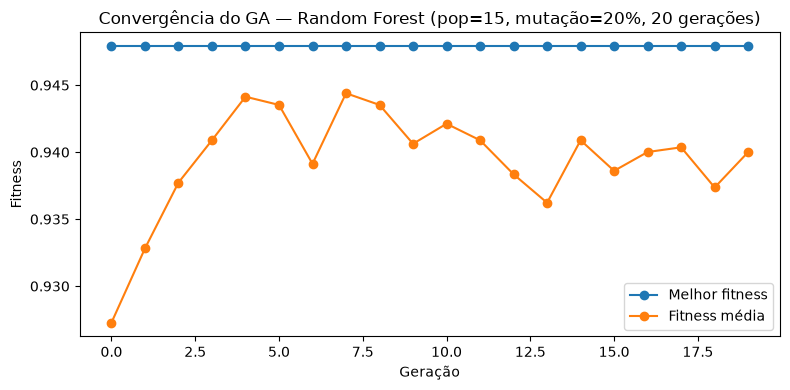

In [ ]:
populacao_rf=20
geracoes_rf=20
mutacao_rf=0.2
populacao, historico_rf, fitnesses, melhor_rf = ga_utils.rodar_ga(
    "random_forest", X_train, y_train, X_test, y_test,
    tamanho_populacao=populacao_rf, geracoes=geracoes_rf, mutacao=mutacao_rf, seed=42,
)
print("\nMelhores hiperparâmetros encontrados:", melhor_rf)

pd.DataFrame(historico_rf).to_csv(RESULTADOS_DIR / "fitness_history_random_forest.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_random_forest.json", "w") as f:
    json.dump({"algoritmo": "random_forest", "melhor_individuo": melhor_rf}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_rf], [h["melhor"] for h in historico_rf], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_rf], [h["media"] for h in historico_rf], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title(f"Convergência do GA — Random Forest (pop={populacao_rf}, mutação={mutacao_rf})")
plt.legend(); plt.tight_layout(); plt.show()

In [7]:
modelo_rf_original = ga_utils.construir_rf(ga_utils.RF_BASELINE)
modelo_rf_original.fit(X_train, y_train)
y_pred_original = modelo_rf_original.predict(X_test)
metricas_rf_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_rf_otimizado = ga_utils.construir_rf(melhor_rf)
modelo_rf_otimizado.fit(X_train, y_train)
y_pred_otimizado = modelo_rf_otimizado.predict(X_test)
metricas_rf_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_rf_original, metricas_rf_otimizado], index=["Original", "Otimizado (GA)"])

,accuracy,precision,recall,f1
Original,0.973684,1.0,0.928571,0.962963
Otimizado (GA),0.973684,1.0,0.928571,0.962963


## Experimento 4 — GA no Random Forest com seleção por roleta

*Por que trocar a seleção?* Os Experimentos 1–3 usam seleção por torneio em todos os casos. Aqui isolamos o efeito de trocar só o operador de seleção, mantendo o resto igual ao Experimento 3 (mesma população, mutação e gerações): em vez de sortear `k` indivíduos e ficar com o melhor deles, a **seleção por roleta** (fitness-proportionate) dá a cada indivíduo uma chance de virar pai proporcional ao seu fitness — indivíduos piores ainda têm alguma chance de reproduzir, só que menor.

**Configuração**: igual ao Experimento 3 (pop=20, mutação=20%, 20 gerações), só troca `selecao_func` para `ga_utils.selecao_roleta`.

Geração 0: melhor=0.9479  média=0.9273  mutação=0.200
Geração 1: melhor=0.9479  média=0.9303  mutação=0.200
Geração 2: melhor=0.9479  média=0.9328  mutação=0.200
Geração 3: melhor=0.9479  média=0.9406  mutação=0.200
Geração 4: melhor=0.9479  média=0.9426  mutação=0.200
Geração 5: melhor=0.9479  média=0.9397  mutação=0.200
Geração 6: melhor=0.9479  média=0.9406  mutação=0.200
Geração 7: melhor=0.9479  média=0.9383  mutação=0.200
Geração 8: melhor=0.9479  média=0.9347  mutação=0.200
Geração 9: melhor=0.9479  média=0.9362  mutação=0.200
Geração 10: melhor=0.9479  média=0.9386  mutação=0.200
Geração 11: melhor=0.9479  média=0.9391  mutação=0.200
Geração 12: melhor=0.9479  média=0.9404  mutação=0.200
Geração 13: melhor=0.9479  média=0.9339  mutação=0.200
Geração 14: melhor=0.9479  média=0.9371  mutação=0.200
Geração 15: melhor=0.9479  média=0.9383  mutação=0.200
Geração 16: melhor=0.9479  média=0.9426  mutação=0.200
Geração 17: melhor=0.9479  média=0.9444  mutação=0.200
Geração 18: melhor=0

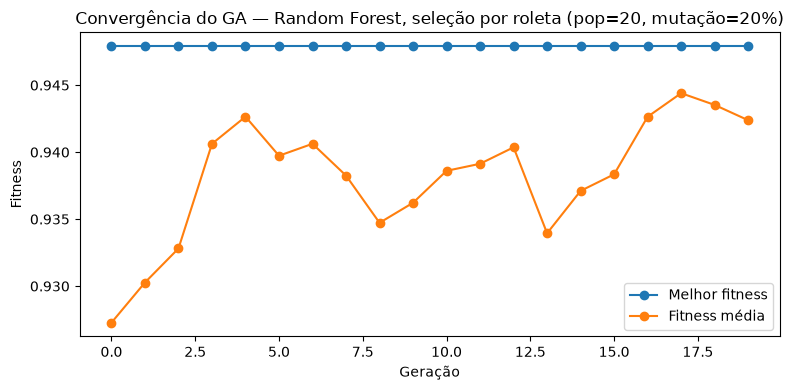

,accuracy,precision,recall,f1
Original,0.973684,1.0,0.928571,0.962963
Experimento 3 (torneio),0.973684,1.0,0.928571,0.962963
Experimento 4 (roleta),0.973684,1.0,0.928571,0.962963


In [ ]:
populacao_rf2=20
geracoes_rf2=20
mutacao_rf2=0.2
populacao, historico_rf_roleta, fitnesses, melhor_rf_roleta = ga_utils.rodar_ga(
    "random_forest", X_train, y_train, X_test, y_test,
    tamanho_populacao=populacao_rf2, geracoes=geracoes_rf2, mutacao=mutacao_rf2,
    selecao_func=ga_utils.selecao_roleta, seed=42,
)
print("\nMelhores hiperparâmetros encontrados:", melhor_rf_roleta)

pd.DataFrame(historico_rf_roleta).to_csv(RESULTADOS_DIR / "fitness_history_random_forest_roleta.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_random_forest_roleta.json", "w") as f:
    json.dump({"algoritmo": "random_forest", "melhor_individuo": melhor_rf_roleta}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_rf_roleta], [h["melhor"] for h in historico_rf_roleta], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_rf_roleta], [h["media"] for h in historico_rf_roleta], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title(f"Convergência do GA — Random Forest, seleção por roleta (pop={populacao_rf2}, mutação={mutacao_rf2})")
plt.legend(); plt.tight_layout(); plt.show()

modelo_rf_roleta = ga_utils.construir_rf(melhor_rf_roleta)
modelo_rf_roleta.fit(X_train, y_train)
y_pred_rf_roleta = modelo_rf_roleta.predict(X_test)
metricas_rf_roleta = ga_utils.calcular_metricas(y_test, y_pred_rf_roleta)

pd.DataFrame(
    [metricas_rf_original, metricas_rf_otimizado, metricas_rf_roleta],
    index=["Original", "Experimento 3 (torneio)", "Experimento 4 (roleta)"],
)

## Experimento 5 — GA na Regressão Logística com mutação adaptativa

*Por que trocar a mutação?* O Experimento 2 usa uma taxa de mutação fixa (20%) durante todas as gerações. Aqui isolamos o efeito de trocar só a mutação, mantendo seleção por torneio e o resto igual ao Experimento 2: a taxa começa em 20% (mesmo valor do Experimento 2) e **decai linearmente até 5%** na última geração — mais exploração no início da busca, mais ajuste fino no final.

**Configuração**: igual ao Experimento 2 (pop=20, 15 gerações), com `mutacao=0.2, mutacao_final=0.05`.

Geração 0: melhor=0.9601  média=0.9522  mutação=0.200
Geração 1: melhor=0.9601  média=0.9577  mutação=0.189
Geração 2: melhor=0.9601  média=0.9575  mutação=0.179
Geração 3: melhor=0.9601  média=0.9592  mutação=0.168
Geração 4: melhor=0.9601  média=0.9575  mutação=0.157
Geração 5: melhor=0.9947  média=0.9601  mutação=0.146
Geração 6: melhor=0.9947  média=0.9699  mutação=0.136
Geração 7: melhor=0.9947  média=0.9797  mutação=0.125
Geração 8: melhor=0.9947  média=0.9817  mutação=0.114
Geração 9: melhor=0.9947  média=0.9941  mutação=0.104
Geração 10: melhor=0.9947  média=0.9892  mutação=0.093
Geração 11: melhor=0.9947  média=0.9930  mutação=0.082
Geração 12: melhor=0.9947  média=0.9921  mutação=0.071
Geração 13: melhor=0.9947  média=0.9913  mutação=0.061
Geração 14: melhor=0.9947  média=0.9921  mutação=0.050

Melhores hiperparâmetros encontrados: {'C': 0.03673046880282847, 'penalty': 'l1', 'class_weight': 'balanced'}


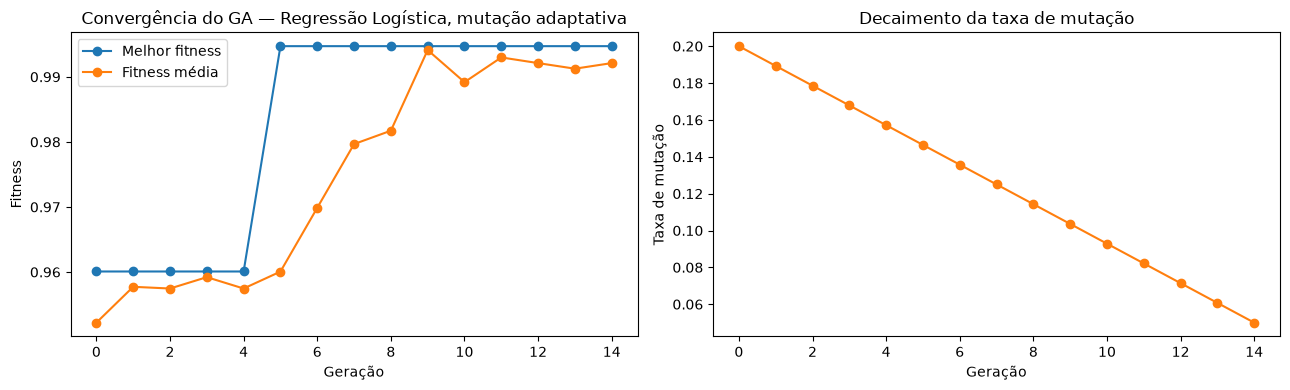

,accuracy,precision,recall,f1
Original,0.973684,0.975610,0.952381,0.963855
Experimento 2 (mutação fixa),0.991228,0.976744,1.000000,0.988235
Experimento 5 (mutação adaptativa),0.991228,0.976744,1.000000,0.988235


In [ ]:
populacao_rlog2=20
geracoes_rlog2=15
mutacao_rlog2=0.2
populacao, historico_log_adaptativo, fitnesses, melhor_log_adaptativo = ga_utils.rodar_ga(
    "regressao_logistica", X_train, y_train, X_test, y_test,
    tamanho_populacao=20, geracoes=15, mutacao=0.2, mutacao_final=0.05, seed=42,
)
print("\nMelhores hiperparâmetros encontrados:", melhor_log_adaptativo)

pd.DataFrame(historico_log_adaptativo).to_csv(RESULTADOS_DIR / "fitness_history_regressao_logistica_mutacao_adaptativa.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_logistica_mutacao_adaptativa.json", "w") as f:
    json.dump({"algoritmo": "regressao_logistica", "melhor_individuo": melhor_log_adaptativo}, f, indent=2, default=str)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot([h["geracao"] for h in historico_log_adaptativo], [h["melhor"] for h in historico_log_adaptativo], label="Melhor fitness", marker="o")
ax1.plot([h["geracao"] for h in historico_log_adaptativo], [h["media"] for h in historico_log_adaptativo], label="Fitness média", marker="o")
ax1.set_xlabel("Geração"); ax1.set_ylabel("Fitness"); ax1.set_title("Convergência do GA — Regressão Logística, mutação adaptativa")
ax1.legend()

ax2.plot([h["geracao"] for h in historico_log_adaptativo], [h["taxa_mutacao"] for h in historico_log_adaptativo], marker="o", color="tab:orange")
ax2.set_xlabel("Geração"); ax2.set_ylabel("Taxa de mutação"); ax2.set_title("Decaimento da taxa de mutação")

plt.tight_layout(); plt.show()

modelo_log_adaptativo = ga_utils.construir_log(melhor_log_adaptativo)
modelo_log_adaptativo.fit(X_train, y_train)
y_pred_log_adaptativo = modelo_log_adaptativo.predict(X_test)
metricas_log_adaptativo = ga_utils.calcular_metricas(y_test, y_pred_log_adaptativo)

pd.DataFrame(
    [metricas_log_original, metricas_log_otimizado, metricas_log_adaptativo],
    index=["Original", "Experimento 2 (mutação fixa)", "Experimento 5 (mutação adaptativa)"],
)

## Comparação final — os 3 algoritmos, original vs. otimizado

Tabela consolidada (também salva em `experiments/results/comparison_table.csv`).

In [10]:
linhas = [
    {"algoritmo": "regressao_linear", "versao": "Original", **metricas_linear_original},
    {"algoritmo": "regressao_linear", "versao": "Otimizado (GA)", **metricas_linear_otimizado},
    {"algoritmo": "regressao_logistica", "versao": "Original", **metricas_log_original},
    {"algoritmo": "regressao_logistica", "versao": "Otimizado (GA)", **metricas_log_otimizado},
    {"algoritmo": "random_forest", "versao": "Original", **metricas_rf_original},
    {"algoritmo": "random_forest", "versao": "Otimizado (GA)", **metricas_rf_otimizado},
]
comparacao_final = pd.DataFrame(linhas)
comparacao_final.to_csv(RESULTADOS_DIR / "comparison_table.csv", index=False)
comparacao_final

,algoritmo,versao,accuracy,precision,recall,f1
0,regressao_linear,Original,0.964912,1.000000,0.904762,0.950000
1,regressao_linear,Otimizado (GA),0.982456,0.976190,0.976190,0.976190
2,regressao_logistica,Original,0.973684,0.975610,0.952381,0.963855
3,regressao_logistica,Otimizado (GA),0.991228,0.976744,1.000000,0.988235
4,random_forest,Original,0.973684,1.000000,0.928571,0.962963
5,random_forest,Otimizado (GA),0.973684,1.000000,0.928571,0.962963


In [11]:
modelos_otimizados = {
    "regressao_linear": (modelo_linear_otimizado, melhor_linear, metricas_linear_otimizado),
    "regressao_logistica": (modelo_log_otimizado, melhor_log, metricas_log_otimizado),
    "random_forest": (modelo_rf_otimizado, melhor_rf, metricas_rf_otimizado),
}

melhor_algoritmo = max(modelos_otimizados, key=lambda nome: (modelos_otimizados[nome][2]["recall"], modelos_otimizados[nome][2]["f1"]))
print(f"Melhor modelo otimizado geral (maior recall, desempate por F1): {melhor_algoritmo}")

Melhor modelo otimizado geral (maior recall, desempate por F1): regressao_logistica


## Feature importances — exame simplificado

O GA não escolhe as medidas uma a uma: ele escolhe os **hiperparâmetros** do modelo. Depois do treino, o próprio modelo diz quais colunas mais pesaram:

- Random Forest → `feature_importances_`
- Regressão Logística / Linear → `|coef_|`

Pegamos as **10 medidas mais importantes do melhor modelo otimizado**, treinamos de novo só com elas e gravamos `experiments/results/feature_importances.json` (cópia em `api/model/`).

A API (`GET /predict/simplificado/features`) e o Angular **não têm essa lista no código**: cada vez que esta seção roda, o formulário simplificado acompanha o ranking novo.

Melhor modelo do GA: regressao_logistica
Importância das medidas em cada modelo otimizado (top 5):

regressao_linear (abs(coef_))
  radius_worst             0.1820
  concave points_worst     0.0954
  texture_worst            0.0714
  symmetry_worst           0.0561
  smoothness_worst         0.0416

regressao_logistica (abs(coef_))
  radius_worst             1.2478
  concave points_worst     0.7332
  concave points_mean      0.4931
  texture_worst            0.3142
  radius_mean              0.0000

random_forest (feature_importances_)
  perimeter_worst          0.4006
  concave points_worst     0.1638
  concave points_mean      0.1228
  radius_worst             0.0924
  area_worst               0.0414

10 medidas exportadas para a API e o Angular:
   1. radius_worst             1.2478
   2. concave points_worst     0.7332
   3. concave points_mean      0.4931
   4. texture_worst            0.3142
   5. radius_mean              0.0000
   6. texture_mean             0.0000
   7. perimet

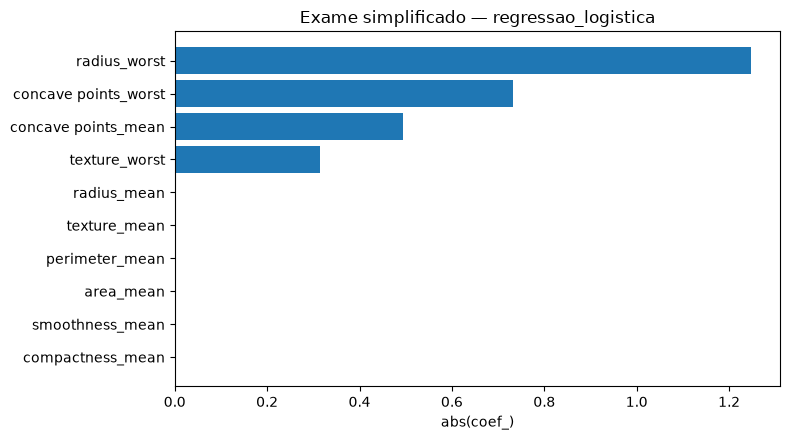

In [12]:
modelo_vencedor, hiper_vencedor, metricas_vencedor = modelos_otimizados[melhor_algoritmo]

print(f"Melhor modelo do GA: {melhor_algoritmo}")
print("Importância das medidas em cada modelo otimizado (top 5):\n")
for nome, (modelo_i, _, _) in modelos_otimizados.items():
    metodo_i, ranking_i = ga_utils.importancias_do_modelo(modelo_i, feature_names)
    print(f"{nome} ({metodo_i})")
    for item in ranking_i[:5]:
        print(f"  {item['feature']:24} {item['importancia']:.4f}")
    print()

exame_simplificado = ga_utils.persistir_exame_simplificado(
    algoritmo=melhor_algoritmo,
    modelo=modelo_vencedor,
    hiperparametros=hiper_vencedor,
    feature_names=feature_names,
)

print("10 medidas exportadas para a API e o Angular:")
for i, item in enumerate(exame_simplificado["features"], start=1):
    print(f"  {i:2}. {item['feature']:24} {item['importancia']:.4f}")
print("\nMétricas do exame simplificado no holdout:", exame_simplificado["metricas_holdout"])
print("Arquivo:", RESULTADOS_DIR / "feature_importances.json")

nomes = [item["feature"] for item in exame_simplificado["features"]][::-1]
pesos = [item["importancia"] for item in exame_simplificado["features"]][::-1]
plt.figure(figsize=(8, 4.5))
plt.barh(nomes, pesos)
plt.xlabel(exame_simplificado["metodo"])
plt.title(f"Exame simplificado — {exame_simplificado['algoritmo']}")
plt.tight_layout()
plt.show()


## Interpretação com LLM (Claude)

Até aqui o notebook está cheio de número: acurácia, recall, `area_worst`, probabilidade... Isso é ótimo pra gente comparar modelo, mas um médico não vai ler a tabela e sair entendendo o exame.

A ideia desta parte é simples: a gente pega o que o modelo já calculou e pede pro Claude escrever em português, como se fosse um colega explicando o resultado. Não é o Claude que diagnostica — ele só traduz o que o modelo já decidiu.

Mandamos dois pedidos:

1. **Laudo de um paciente** — o mesmo tipo de texto que a API e o front mostram: deu positivo ou negativo, qual a chance de ser maligno e por quê (tamanho, textura, formato).
2. **Relatório dos experimentos** — um resumo de qual modelo ganhou depois do GA e quais medidas do tumor mais pesaram.

O texto que a gente “ensina” o Claude a seguir (o prompt) está em `src/llm_utils.py`. Separar o papel dele dos números do paciente evita que ele invente exame ou fale em hiperparâmetro no laudo.

Para esta célula funcionar, a chave da Anthropic precisa estar no arquivo `.env`.

In [13]:
modelo_final, hiperparametros_final, metricas_final = modelos_otimizados[melhor_algoritmo]
y_pred_final = ga_utils.prever_modelo(melhor_algoritmo, modelo_final, X_test, hiperparametros_final)

idx = next((i for i in range(len(y_pred_final)) if int(y_pred_final[i]) == 1), 0)
predicao_texto = "Maligno" if int(y_pred_final[idx]) == 1 else "Benigno"
if hasattr(modelo_final, "predict_proba"):
    chance_doenca = float(modelo_final.predict_proba(X_test[idx : idx + 1])[0][1])
else:
    chance_doenca = float(np.clip(modelo_final.predict(X_test[idx : idx + 1])[0], 0, 1))

valores_originais = scaler.inverse_transform(X_test[idx : idx + 1])[0]
features_paciente = llm_utils.obter_features_importantes(
    modelo_final, feature_names, valores_originais
)
prompt_laudo = llm_utils.montar_prompt(
    predicao=predicao_texto,
    chance_doenca=chance_doenca,
    features_importantes=features_paciente,
    accuracy=metricas_final["accuracy"],
    recall=metricas_final["recall"],
    f1=metricas_final["f1"],
    contexto_ga=llm_utils.formatar_contexto_ga(melhor_algoritmo, hiperparametros_final),
)
prompt_relatorio = llm_utils.montar_prompt_relatorio(
    comparacao=comparacao_final,
    melhor_algoritmo=melhor_algoritmo,
    hiperparametros=hiperparametros_final,
    metricas=metricas_final,
    features_top=exame_simplificado["features"],
)

chave = llm_utils.carregar_chave_do_env()
if not chave:
    print("Preencha ANTHROPIC_API_KEY no .env na raiz do projeto para o Claude escrever os textos.")
else:
    laudo = llm_utils.gerar_explicacao(prompt_laudo, api_key=chave)
    relatorio = llm_utils.gerar_explicacao(
        prompt_relatorio,
        api_key=chave,
        system_prompt=llm_utils.SYSTEM_PROMPT_RELATORIO,
        max_tokens=700,
    )
    print("=== Laudo de um paciente (mesmo tipo da API) ===\n")
    print(laudo)
    print("\n=== Relatório dos experimentos do GA ===\n")
    print(relatorio)
    (RESULTADOS_DIR / "relatorio_llm.txt").write_text(
        "LAUDO\n\n" + laudo + "\n\nRELATÓRIO\n\n" + relatorio,
        encoding="utf-8",
    )


=== Laudo de um paciente (mesmo tipo da API) ===

**LAUDO DE TRIAGEM AUTOMÁTICA — CÂNCER DE MAMA**

**Resultado: POSITIVO — Indica doença (tumor maligno)**

Nossa detecção automática deu **99% de chance de o tumor ser maligno**, principalmente por causa do tamanho muito aumentado do tumor — raio de 25,580 — e da irregularidade bem marcada no contorno, com múltiplos pontos côncavos. Essas características são sinais clássicos de malignidade e pesaram bastante na conclusão.

A chance de se tratar de um tumor benigno é de apenas 1%, o que torna o resultado bastante sugestivo de doença.

**Importante:** Este é um resultado de triagem automática e não substitui o diagnóstico médico definitivo. Recomenda-se investigação clínica e confirmação histológica para o manejo adequado do paciente.

=== Relatório dos experimentos do GA ===

# Relatório de Otimização do Sistema de Triagem de Câncer de Mama

O modelo de **Regressão Logística** apresentou o melhor desempenho após otimização automática. A 

## Avaliação das interpretações

Não tem uma nota automática do tipo “o laudo tirou 9,2”. A gente lê o que o Claude escreveu e vê se está honesto e útil.

No laudo: ele começou dizendo se deu positivo ou negativo? A porcentagem é a mesma que o modelo calculou? Ele fala do tumor (tamanho, textura, contorno) sem inventar outro exame? No final ele deixa claro que isso é uma triagem, não um diagnóstico médico?

No relatório: ele aponta o mesmo vencedor da tabela de cima? As medidas que ele cita são as que exportamos no exame simplificado?

Se alguma coisa escapar — um número inventado, um termo de machine learning no meio do laudo — o problema quase sempre está no que a gente pediu, em `src/llm_utils.py`. Aí a gente ajusta o prompt e roda de novo.

## Conclusão

- Os 3 algoritmos do notebook 01 foram otimizados via Algoritmo Genético, cada um com um espaço de genes adequado ao seu tipo de hiperparâmetro.
- 5 experimentos ao todo: 3 com configurações diferentes do GA (população/mutação/gerações), um por algoritmo (Experimentos 1–3); mais 2 isolando a troca de um único operador — seleção por roleta no Random Forest (Experimento 4, vs. torneio no Experimento 3) e mutação adaptativa na Regressão Logística (Experimento 5, vs. taxa fixa no Experimento 2).
- A tabela de comparação (`experiments/results/comparison_table.csv`) mostra o ganho (ou não) de cada modelo otimizado em relação ao baseline, considerando os Experimentos 1–3.
- Os Experimentos 4 e 5 não entram na escolha do modelo de produção nem na exportação de `feature_importances.json` — servem só pra comparar operadores do GA entre si.
- As feature importances do vencedor (entre os Experimentos 1–3) vão para `feature_importances.json`; a API e o Angular montam o exame simplificado a partir desse arquivo.
- A LLM gera um laudo de paciente (igual à API) e um relatório dos experimentos. Os prompts estão em `src/llm_utils.py`.
